<a href="https://colab.research.google.com/github/Anannya-Vyas/MACHINE-LEARNING-FROM-SCRATCH-/blob/main/knn_TitanicModels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = sns.load_dataset("titanic")

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
df.drop(["deck", "embark_town", "alive", "class", "who", "adult_male"], axis=1, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
 8   alone     891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 56.7+ KB


In [ ]:
df["age"].fillna(df["age"].mean(), inplace=True)

In [ ]:
df.dropna(subset=["embarked"], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  889 non-null    int64  
 1   pclass    889 non-null    int64  
 2   sex       889 non-null    object 
 3   age       889 non-null    float64
 4   sibsp     889 non-null    int64  
 5   parch     889 non-null    int64  
 6   fare      889 non-null    float64
 7   embarked  889 non-null    object 
 8   alone     889 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 63.4+ KB


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


In [ ]:
df['sex'] = le.fit_transform(df['sex'])
df["embarked"] = le.fit_transform(df["embarked"]) # S=2, C=0, Q=1

In [ ]:
# Removed df = df.astype(int) to preserve fare values as floats

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22.0,1,0,7.2500,2,False
1,1,1,0,38.0,1,0,71.2833,0,False
2,1,3,0,26.0,0,0,7.9250,2,True
3,1,1,0,35.0,1,0,53.1000,2,False
4,0,3,1,35.0,0,0,8.0500,2,True


In [ ]:
X = df.drop("survived", axis=1)
y = df["survived"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [ ]:
# knn_model = KNeighborsClassifier(n_neighbors= best_k)
# knn_model.fit(X_train_scaled,y_train)

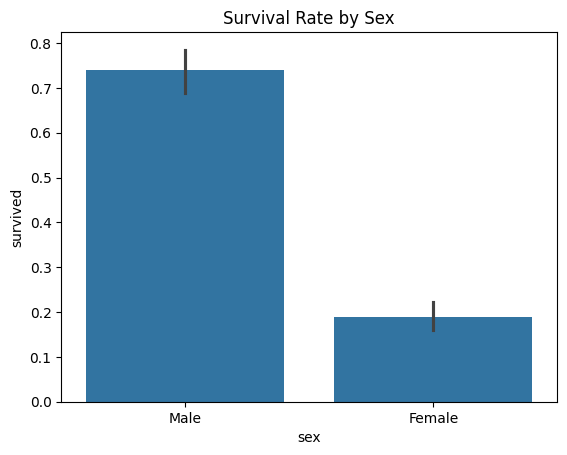

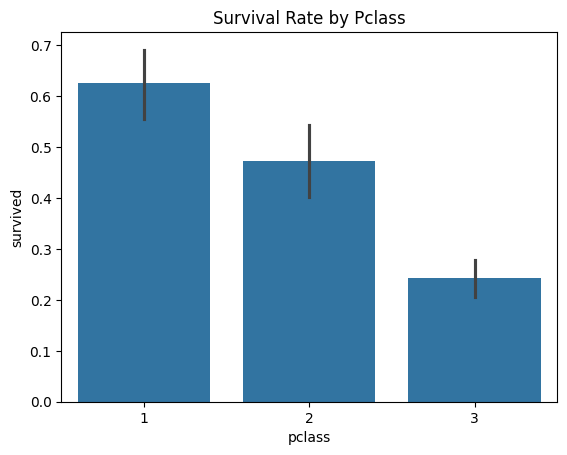

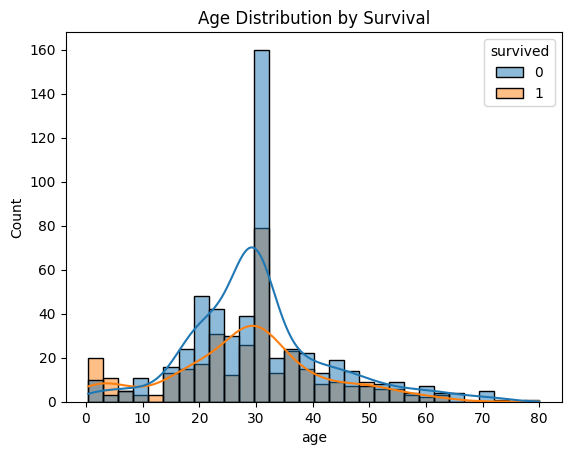

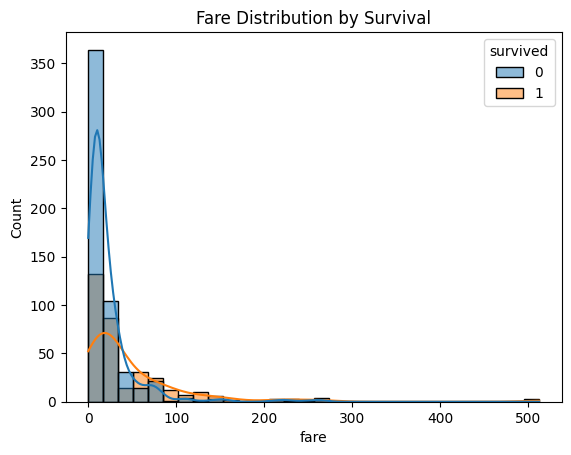

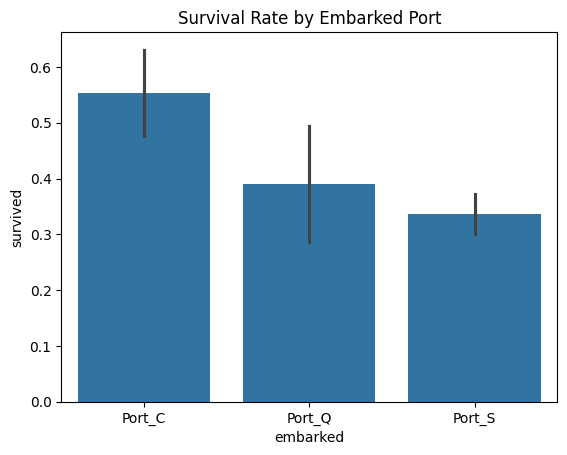

In [ ]:
# Survival Rate by Sex
sns.barplot(x='sex', y='survived', data=df)
plt.title('Survival Rate by Sex')
plt.xticks(ticks=[0, 1], labels=['Male', 'Female']) # Corrected labels
plt.show()

# Survival Rate by Pclass
sns.barplot(x='pclass', y='survived', data=df)
plt.title('Survival Rate by Pclass')
plt.show()

# Distribution of Age for Survived vs. Not Survived
sns.histplot(data=df, x='age', hue='survived', kde=True, bins=30)
plt.title('Age Distribution by Survival')
plt.show()

# Distribution of Fare for Survived vs. Not Survived
sns.histplot(data=df, x='fare', hue='survived', kde=True, bins=30)
plt.title('Fare Distribution by Survival')
plt.show()

# Survival Rate by Embarked Port
sns.barplot(x='embarked', y='survived', data=df)
plt.title('Survival Rate by Embarked Port')
# Assuming 0, 1, 2 map to S, C, Q or similar after LabelEncoding, adjust labels if needed
plt.xticks(ticks=[0, 1, 2], labels=['Port_C', 'Port_Q', 'Port_S']) # Adjusted labels based on LabelEncoder output
plt.show()

In [ ]:
# y_pred_knn = knn_model.predict(X_test_scaled)

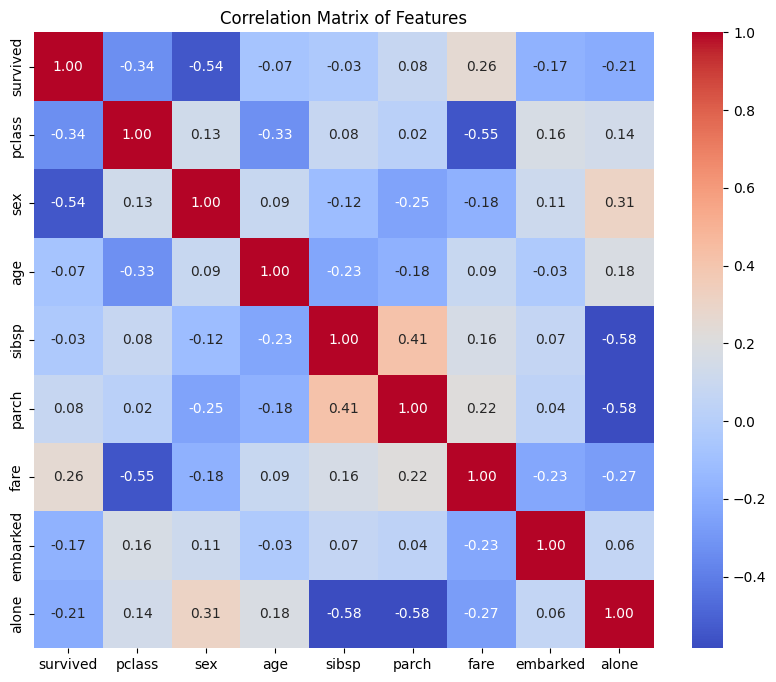

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

In [ ]:
# accuracy_score(y_test,y_pred_knn)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# confusion_matrix(y_test,y_pred_knn)

In [ ]:
# print(classification_report(y_test,y_pred_knn))

In [ ]:
# print(f"KNN Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
# print(classification_report(y_test, y_pred_knn))

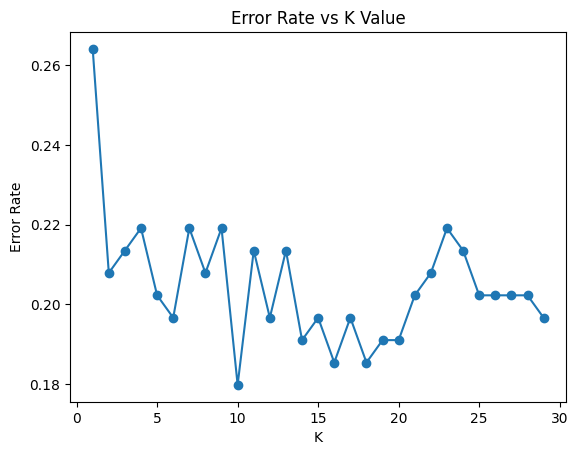

Best K: 10


In [ ]:
error_rates = []
for k in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    preds = knn.predict(X_test_scaled)
    error_rates.append(1 - accuracy_score(y_test, preds))

plt.plot(range(1, 30), error_rates, marker='o')
plt.title('Error Rate vs K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

best_k = error_rates.index(min(error_rates)) + 1
print(f"Best K: {best_k}")

### Step 1: Find the Best K Value

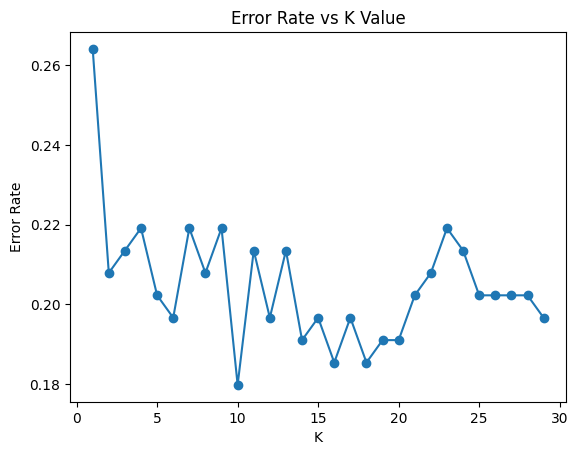

Best K: 10


In [ ]:
error_rates = []
for k in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    preds = knn.predict(X_test_scaled)
    error_rates.append(1 - accuracy_score(y_test, preds))

plt.plot(range(1, 30), error_rates, marker='o')
plt.title('Error Rate vs K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

best_k = error_rates.index(min(error_rates)) + 1
print(f"Best K: {best_k}")

### Step 2: Retrain KNN model with the Best K Value and Evaluate

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)
print(f"KNN Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8202
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       109
           1       0.78      0.74      0.76        69

    accuracy                           0.82       178
   macro avg       0.81      0.81      0.81       178
weighted avg       0.82      0.82      0.82       178



### Step 3: Save the Model and Scaler

In [ ]:
import joblib
joblib.dump(knn_model, 'knn_titanic_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and scaler saved.")

Model and scaler saved.


In [ ]:
# y_pred_knn = knn_model.predict(X_test_scaled)
# print(f"KNN Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
# print(classification_report(y_test, y_pred_knn))

In [ ]:
import joblib
joblib.dump(knn_model, 'knn_titanic_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and scaler saved.")

Model and scaler saved.
